In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [76]:
df = pd.read_csv("dataset_sucio_practica.csv")

In [9]:
df.shape

(125, 8)

In [10]:
df.head(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [12]:
df.tail(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
124,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [13]:
df.describe(include="all")

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
count,125.000000,116,110.000000,125,82,107.000000,125,90
unique,NaN,112,NaN,109,3,NaN,106,2
top,NaN,Julia Zhang,NaN,correo_invalido,Argentina,NaN,2026-05-02,Sí
freq,NaN,2,NaN,14,31,NaN,3,49
mean,58.200000,NaN,43.945455,NaN,NaN,14093.457944,NaN,NaN
std,35.906465,NaN,47.489803,NaN,NaN,8825.918852,NaN,NaN
min,1.000000,NaN,-5.000000,NaN,NaN,-1000.000000,NaN,NaN
25%,27.000000,NaN,22.750000,NaN,NaN,12000.000000,NaN,NaN
50%,58.000000,NaN,30.000000,NaN,NaN,15000.000000,NaN,NaN
75%,89.000000,NaN,40.000000,NaN,NaN,18000.000000,NaN,NaN


In [17]:
df[df["id"].isin([29, 55, 58])]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
54,55,John Lewis,NaN,rodriguezbrett@yahoo.com,México,-1000.0,2024-07-03,NaN
57,58,Michael Barajas,40.0,antoniocox@hotmail.com,España,15000.0,2026-05-02,NaN


In [18]:
dfCopy = df.copy()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    object 
 2   edad            110 non-null    float64
 3   correo          125 non-null    object 
 4   pais            82 non-null     object 
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    object 
 7   activo          90 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ KB


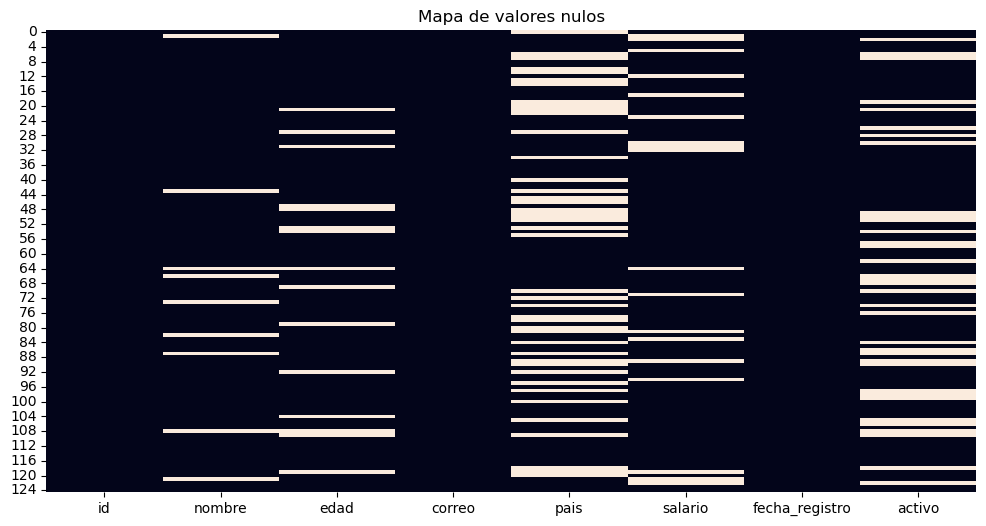

In [22]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

In [24]:
#Limpieza de datos
df.duplicated().sum()

5

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.duplicated().sum()

0

In [31]:
df[(df["edad"] < 0) | (df["edad"] > 110) ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [33]:
df.loc[(df["edad"] < 0) | (df["edad"] > 110), "edad"] = np.nan

In [34]:
df[(df["edad"] < 0) | (df["edad"] > 110) ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [35]:
#Calcular mediana de edad 
mediana_edad=df["edad"].median()

In [36]:
mediana_edad

30.0

In [37]:
df["edad"]= df["edad"].fillna(mediana_edad)

In [38]:
df["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [40]:
df[df["salario"] < 0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
9,10,Angela Richards,30.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
11,12,Daniel Wright,25.0,melissamaxwell@gmail.com,NaN,-1000.0,2024-12-20,Sí
20,21,Marc Miller DDS,30.0,ccalderon@campbell-carter.com,NaN,-1000.0,2024-06-25,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
26,27,Mary Miranda,40.0,brendaglenn@gmail.com,Argentina,-1000.0,2025-06-01,NaN
27,28,John Taylor,30.0,jonesashley@hotmail.com,NaN,-1000.0,2025-08-02,No
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
37,38,Brian Sherman,30.0,brianna61@yahoo.com,Argentina,-1000.0,2024-09-17,Sí
41,42,Patricia Morrison,30.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
44,45,John Estrada,35.0,nichole26@hotmail.com,Argentina,-1000.0,2025-12-12,Sí


In [41]:
df.loc[(df["salario"] < 0), "salario"] = np.nan

In [42]:
df[df["salario"] < 0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [43]:
mediana_salario = df["salario"].median()

In [44]:
mediana_salario

15000.0

In [45]:
df["salario"] = df["salario"].fillna(mediana_salario)

In [46]:
df["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [51]:
#Corregir correos no validos
df[~df["correo"].str.contains("@", na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,30.0,<NA>,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,<NA>,España,15000.0,2026-05-04,No
2,3,George Burke,40.0,<NA>,Argentina,15000.0,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,correo_invalido,México,25000.0,2025-03-28,Sí
...,...,...,...,...,...,...,...,...
115,116,Samuel Roth,30.0,<NA>,España,12000.0,2024-12-10,Sí
116,117,Kristina Buchanan,30.0,<NA>,Argentina,18000.0,2024-11-18,No
117,118,Michael Harper,30.0,<NA>,Argentina,12000.0,2026-04-29,No
118,119,Kristopher Hampton,30.0,<NA>,NaN,15000.0,2025-07-08,NaN


In [50]:
#Corregir correos no validos
correo_invalido=df["correo"].str.contains("@", na = False)
df.loc[correo_invalido, "correo"]= pd.NA

In [56]:
#Corregir paises no asignados
df["pais"].isnull().sum()

0

In [53]:
moda_pais = df["pais"].mode()[0]

In [54]:
moda_pais

'Argentina'

In [55]:
df["pais"]= df["pais"].fillna(moda_pais)

In [60]:
df.dtypes

id                         int64
nombre                    object
edad                     float64
correo                    object
pais                      object
salario                  float64
fecha_registro    datetime64[ns]
activo                    object
dtype: object

In [59]:
#Convertir fecha en datetime
df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])

In [61]:
df["fecha_registro"].dt.year

0      2026
1      2026
2      2026
3      2025
4      2025
       ... 
115    2024
116    2024
117    2026
118    2025
119    2026
Name: fecha_registro, Length: 120, dtype: int32

In [78]:
#Categorizar el campo activo
df["activo"].value_counts(dropna=False)

activo
1.0    49
0.0    41
NaN    35
Name: count, dtype: int64

In [64]:
df["activo"] = df["activo"].fillna("Si")

In [72]:
df["activo"] = df["activo"].map({
    "Sí": 1, "No": 0
})

In [73]:
df["activo"].value_counts(dropna=False)

activo
NaN    120
Name: count, dtype: int64

In [ ]:
(df.isnull().sum()/len (df)*100)